In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import math
import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor, Normalize, Compose
from torch.utils.data import DataLoader, random_split


LoRA model trainable parameters: 6,224 (2.26% of total)
Regular model trainable parameters: 269,322
Using device: cpu
Training LoRA model...
Epoch: 1/3 [0/60000 (0%)]	Loss: 2.296375
Epoch: 1/3 [6400/60000 (11%)]	Loss: 1.077360
Epoch: 1/3 [12800/60000 (21%)]	Loss: 0.587261
Epoch: 1/3 [19200/60000 (32%)]	Loss: 0.475280
Epoch: 1/3 [25600/60000 (43%)]	Loss: 0.668757
Epoch: 1/3 [32000/60000 (53%)]	Loss: 0.400182
Epoch: 1/3 [38400/60000 (64%)]	Loss: 0.428668
Epoch: 1/3 [44800/60000 (75%)]	Loss: 0.593736
Epoch: 1/3 [51200/60000 (85%)]	Loss: 0.415727
Epoch: 1/3 [57600/60000 (96%)]	Loss: 0.484588
Epoch: 1/3, Test Accuracy: 88.87%, Avg Train Loss: 0.616071
Epoch: 2/3 [0/60000 (0%)]	Loss: 0.458034
Epoch: 2/3 [6400/60000 (11%)]	Loss: 0.335511
Epoch: 2/3 [12800/60000 (21%)]	Loss: 0.407473
Epoch: 2/3 [19200/60000 (32%)]	Loss: 0.272585
Epoch: 2/3 [25600/60000 (43%)]	Loss: 0.402463
Epoch: 2/3 [32000/60000 (53%)]	Loss: 0.323472
Epoch: 2/3 [38400/60000 (64%)]	Loss: 0.634406
Epoch: 2/3 [44800/60000 (75%)

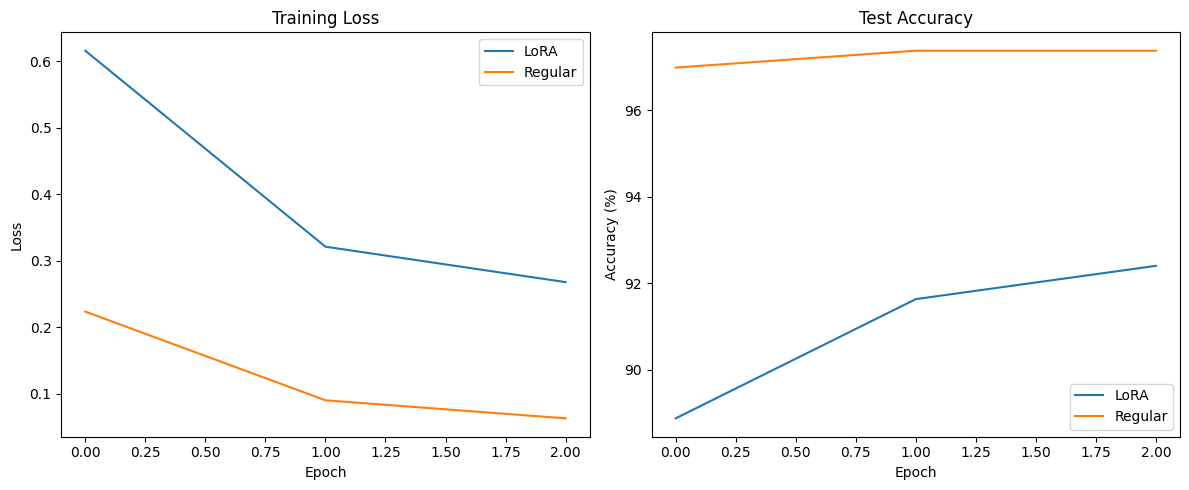

Error in weight visualization: Image data of dtype object cannot be converted to float
Continuing with training and performance comparison...


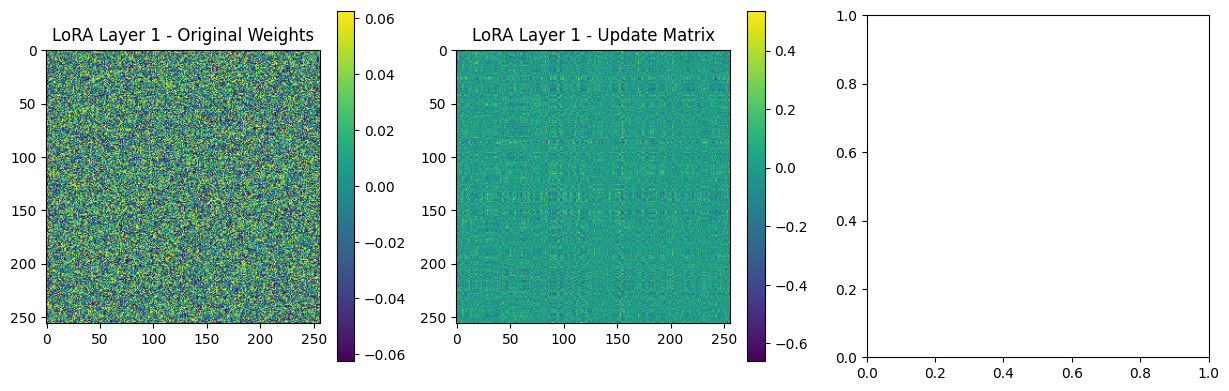

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import numpy as np
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

class LoRALayer(nn.Module):
    """
    Implementation of a LoRA (Low-Rank Adaptation) layer
    """
    def __init__(self, in_features, out_features, rank=4, alpha=1.0):
        super(LoRALayer, self).__init__()

        # Original weight matrix (frozen)
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))

        # Low-rank matrices for adaptation
        # Note: lora_A has shape (in_features, rank) and lora_B has shape (rank, out_features)
        self.lora_A = nn.Parameter(torch.Tensor(in_features, rank))
        self.lora_B = nn.Parameter(torch.Tensor(rank, out_features))

        # Scaling factor
        self.alpha = alpha
        self.rank = rank

        # Bias term
        self.bias = nn.Parameter(torch.Tensor(out_features))

        # Initialize weights
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)  # Initialize B to zero so LoRA starts as identity
        nn.init.zeros_(self.bias)

    def forward(self, x):
        # Original forward pass - F.linear expects weights as (out_features, in_features)
        original_output = F.linear(x, self.weight, self.bias)

        # LoRA adaptation path: x @ A @ B
        # First multiply x by A: (batch_size, in_features) @ (in_features, rank) = (batch_size, rank)
        lora_output = x @ self.lora_A
        # Then multiply by B: (batch_size, rank) @ (rank, out_features) = (batch_size, out_features)
        lora_output = lora_output @ self.lora_B

        # Apply scaling factor to LoRA output and add to original output
        return original_output + (self.alpha / self.rank) * lora_output

# Let's create a simple LoRA-enabled MLP for MNIST
class LoRAMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, output_dim=10, rank=4, alpha=1.0):
        super(LoRAMLP, self).__init__()

        # Define layers
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = LoRALayer(hidden_dim, hidden_dim, rank=rank, alpha=alpha)
        self.fc3 = LoRALayer(hidden_dim, output_dim, rank=rank, alpha=alpha)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten the input
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Function to count trainable parameters
def count_parameters(model):
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    return trainable_params, total_params

# Training function for the models
def train_model(model, train_loader, test_loader, optimizer, criterion, epochs=3, device='cpu'):
    model.to(device)
    train_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        samples = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * data.size(0)
            samples += data.size(0)

            if batch_idx % 100 == 0:
                print(f'Epoch: {epoch+1}/{epochs} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                      f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

        epoch_loss = running_loss / samples
        train_losses.append(epoch_loss)

        # Evaluate on test set
        model.eval()
        correct = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(target.view_as(pred)).sum().item()

        accuracy = 100. * correct / len(test_loader.dataset)
        test_accuracies.append(accuracy)
        print(f'Epoch: {epoch+1}/{epochs}, Test Accuracy: {accuracy:.2f}%, Avg Train Loss: {epoch_loss:.6f}')

    return train_losses, test_accuracies

# Function to get weights from models for visualization
def get_layer_weights(model, layer_index):
    if isinstance(model, LoRAMLP):
        if layer_index == 1:
            original_weight = model.fc2.weight.data.cpu().numpy()
            lora_A = model.fc2.lora_A.data.cpu().numpy()  # (in_features, rank)
            lora_B = model.fc2.lora_B.data.cpu().numpy()  # (rank, out_features)
            # Compute the low-rank update matrix: A @ B
            lora_update = (model.fc2.alpha / model.fc2.rank) * np.matmul(lora_A, lora_B)
            return original_weight, lora_update
        elif layer_index == 2:
            original_weight = model.fc3.weight.data.cpu().numpy()
            lora_A = model.fc3.lora_A.data.cpu().numpy()  # (in_features, rank)
            lora_B = model.fc3.lora_B.data.cpu().numpy()  # (rank, out_features)
            # Compute the low-rank update matrix
            lora_update = (model.fc3.alpha / model.fc3.rank) * np.matmul(lora_A, lora_B)
            return original_weight, lora_update
    else:
        # For regular model, we need to get the linear layers directly
        if isinstance(model, nn.Sequential):
            linear_layers = [m for m in model if isinstance(m, nn.Linear)]
            if layer_index <= len(linear_layers):
                # Subtract 1 because Python is 0-indexed, but our layer_index starts at 1
                return linear_layers[layer_index-1].weight.data.cpu().numpy(), None

    return None, None

# Create a regular model with a more explicit structure for visualization
class RegularMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, output_dim=10):
        super(RegularMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten the input
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Create models for comparison
lora_model = LoRAMLP(rank=8, alpha=16.0)
regular_model = RegularMLP()  # Use our new explicit model

# Make the original weights non-trainable for LoRA fine-tuning
for name, param in lora_model.named_parameters():
    if 'lora' not in name:  # Freeze all non-LoRA parameters
        param.requires_grad = False

lora_trainable, lora_total = count_parameters(lora_model)
print(f"LoRA model trainable parameters: {lora_trainable:,} ({lora_trainable/lora_total:.2%} of total)")

regular_trainable, regular_total = count_parameters(regular_model)
print(f"Regular model trainable parameters: {regular_trainable:,}")

# Set up the device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set up data loaders
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Set up optimizers and criterion
criterion = nn.CrossEntropyLoss()
lora_optimizer = torch.optim.Adam([p for p in lora_model.parameters() if p.requires_grad], lr=0.001)
regular_optimizer = torch.optim.Adam(regular_model.parameters(), lr=0.001)

# Train LoRA model
print("Training LoRA model...")
lora_train_losses, lora_test_accuracies = train_model(
    lora_model, train_loader, test_loader, lora_optimizer, criterion, epochs=3, device=device
)

# Train regular model
print("\nTraining regular model...")
regular_train_losses, regular_test_accuracies = train_model(
    regular_model, train_loader, test_loader, regular_optimizer, criterion, epochs=3, device=device
)

# Compare the results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lora_train_losses, label='LoRA')
plt.plot(regular_train_losses, label='Regular')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(lora_test_accuracies, label='LoRA')
plt.plot(regular_test_accuracies, label='Regular')
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.savefig('lora_vs_regular_performance.png')
plt.show()

# Get weights for visualization
try:
    # Get weights from LoRA model
    lora_layer1_original, lora_layer1_update = get_layer_weights(lora_model, 1)
    lora_layer2_original, lora_layer2_update = get_layer_weights(lora_model, 2)

    # Get weights from regular model
    regular_layer1, _ = get_layer_weights(regular_model, 1)
    regular_layer2, _ = get_layer_weights(regular_model, 2)

    # Plot weights as heatmaps
    plt.figure(figsize=(15, 10))

    # Layer 1 weights
    plt.subplot(2, 3, 1)
    plt.imshow(lora_layer1_original, cmap='viridis')
    plt.colorbar()
    plt.title('LoRA Layer 1 - Original Weights')

    plt.subplot(2, 3, 2)
    plt.imshow(lora_layer1_update, cmap='viridis')
    plt.colorbar()
    plt.title('LoRA Layer 1 - Update Matrix')

    plt.subplot(2, 3, 3)
    plt.imshow(regular_layer1, cmap='viridis')
    plt.colorbar()
    plt.title('Regular Layer 1 Weights')

    # Layer 2 weights
    plt.subplot(2, 3, 4)
    plt.imshow(lora_layer2_original, cmap='viridis')
    plt.colorbar()
    plt.title('LoRA Layer 2 - Original Weights')

    plt.subplot(2, 3, 5)
    plt.imshow(lora_layer2_update, cmap='viridis')
    plt.colorbar()
    plt.title('LoRA Layer 2 - Update Matrix')

    plt.subplot(2, 3, 6)
    plt.imshow(regular_layer2, cmap='viridis')
    plt.colorbar()
    plt.title('Regular Layer 2 Weights')

    plt.tight_layout()
    plt.savefig('lora_vs_regular_weights.png')
    plt.show()

    # Plot histograms of weight distributions
    plt.figure(figsize=(15, 10))

    # Layer 1 histograms
    plt.subplot(2, 3, 1)
    plt.hist(lora_layer1_original.flatten(), bins=50, alpha=0.7)
    plt.title('LoRA Layer 1 - Original Weights')

    plt.subplot(2, 3, 2)
    plt.hist(lora_layer1_update.flatten(), bins=50, alpha=0.7)
    plt.title('LoRA Layer 1 - Update Matrix')

    plt.subplot(2, 3, 3)
    plt.hist(regular_layer1.flatten(), bins=50, alpha=0.7)
    plt.title('Regular Layer 1 Weights')

    # Layer 2 histograms
    plt.subplot(2, 3, 4)
    plt.hist(lora_layer2_original.flatten(), bins=50, alpha=0.7)
    plt.title('LoRA Layer 2 - Original Weights')

    plt.subplot(2, 3, 5)
    plt.hist(lora_layer2_update.flatten(), bins=50, alpha=0.7)
    plt.title('LoRA Layer 2 - Update Matrix')

    plt.subplot(2, 3, 6)
    plt.hist(regular_layer2.flatten(), bins=50, alpha=0.7)
    plt.title('Regular Layer 2 Weights')

    plt.tight_layout()
    plt.savefig('lora_vs_regular_weight_distributions.png')
    plt.show()

except Exception as e:
    print(f"Error in weight visualization: {e}")
    print("Continuing with training and performance comparison...")

In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# Simplified quantization function
def quantize_model_weights(model, bits=8):
    """Quantize the weights of a model to the specified bit precision"""
    quantization_params = {}

    for name, param in model.named_parameters():
        # Only quantize frozen weights (not LoRA or trainable parameters)
        if 'lora' not in name and not param.requires_grad and 'weight' in name:
            weight = param.data

            # Simple quantization for any shape tensor
            min_val = weight.min().item()
            max_val = weight.max().item()

            scale = (max_val - min_val) / (2**bits - 1)
            if scale == 0 or torch.isnan(torch.tensor(scale)):  # Handle zero range or NaN
                scale = 1.0

            zero_point = -round(min_val / scale)
            zero_point = max(0, min(2**bits - 1, zero_point))

            # Quantize the whole tensor
            quantized = torch.clamp(torch.round(weight / scale) + zero_point,
                                   0, 2**bits - 1).to(torch.int8)

            # Store parameters
            quantization_params[name] = {
                'original': weight.clone(),
                'quantized': quantized,
                'scale': scale,
                'zero_point': zero_point,
                'bits': bits
            }

            # Replace weights - keep dtype the same
            param.data = (quantized.to(torch.float32) - zero_point) * scale

    return quantization_params

# Function to restore original model weights
def restore_model_weights(model, quantization_params):
    """Restore the original weights of a model after quantization"""
    for name, param_dict in quantization_params.items():
        param = dict(model.named_parameters())[name]
        param.data = param_dict['original'].clone()

# LoRA version of linear layer
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, rank=8, alpha=16, dropout=0.0):
        super(LoRALinear, self).__init__()
        # Original linear layer (frozen)
        self.linear = nn.Linear(in_features, out_features)

        # LoRA components
        self.lora_down = nn.Linear(in_features, rank, bias=False)
        self.lora_up = nn.Linear(rank, out_features, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.alpha = alpha
        self.rank = rank

        # Initialize LoRA weights
        nn.init.kaiming_uniform_(self.lora_down.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_up.weight)

        # Freeze the original weights
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False

    def forward(self, x):
        # Original path
        original_output = self.linear(x)

        # LoRA path
        lora_down_output = self.lora_down(x)
        lora_down_output = self.dropout(lora_down_output)
        lora_output = self.lora_up(lora_down_output)

        # Combine with scaling
        return original_output + (self.alpha / self.rank) * lora_output

# Function to convert model to LoRA
def convert_to_lora(model, rank=8, alpha=16, dropout=0.0, target_modules=None):
    """Convert a regular model to a LoRA-enabled model"""
    if target_modules is None:
        target_modules = [nn.Linear]

    # Keep track of the original state dict
    original_state_dict = {k: v.clone() for k, v in model.state_dict().items()}

    # Convert Linear layers to LoRA Linear
    for name, module in list(model.named_modules()):
        # Check if we should apply LoRA to this module
        if any(isinstance(module, module_type) for module_type in target_modules):
            # Get the parent module
            parent_name = '.'.join(name.split('.')[:-1])
            child_name = name.split('.')[-1]
            parent = model if parent_name == '' else model.get_submodule(parent_name)

            # Create LoRA equivalent
            if isinstance(module, nn.Linear):
                lora_module = LoRALinear(
                    module.in_features,
                    module.out_features,
                    rank=rank,
                    alpha=alpha,
                    dropout=dropout
                )

                # Copy weights
                lora_module.linear.weight.data.copy_(module.weight.data)
                if module.bias is not None:
                    lora_module.linear.bias.data.copy_(module.bias.data)

                # Replace the module
                setattr(parent, child_name, lora_module)

    # Freeze all parameters except LoRA parameters
    for name, param in model.named_parameters():
        if 'lora' not in name:
            param.requires_grad = False

    return model, original_state_dict

# Calculate parameter counts
def count_params_by_type(model):
    """Count trainable, frozen, and total parameters in a model"""
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    total_params = trainable_params + frozen_params
    lora_params = sum(p.numel() for name, p in model.named_parameters()
                     if 'lora' in name and p.requires_grad)

    return {
        'trainable': trainable_params,
        'frozen': frozen_params,
        'total': total_params,
        'lora': lora_params,
        'trainable_pct': trainable_params / total_params * 100,
        'lora_pct': lora_params / total_params * 100
    }

# Example language model - simplified for demonstration
class SimpleLanguageModel(nn.Module):
    def __init__(self, vocab_size=10000, embed_dim=256, num_heads=4, ff_dim=1024, num_layers=2):
        super(SimpleLanguageModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # Simple linear layers instead of full transformer for simplicity
        self.layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(embed_dim, ff_dim),
                nn.ReLU(),
                nn.Linear(ff_dim, embed_dim)
            ) for _ in range(num_layers)
        ])

        self.output = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)

        for layer in self.layers:
            x = layer(x) + x  # Residual connection

        return self.output(x)

# Function to compare model configurations
def compare_model_configs():
    """Compare parameter counts and memory usage for different model configurations"""
    # Create base model
    base_model = SimpleLanguageModel()
    base_params = count_params_by_type(base_model)

    # Create LoRA model
    lora_model = SimpleLanguageModel()
    lora_model, _ = convert_to_lora(lora_model, rank=16, alpha=32)
    lora_params = count_params_by_type(lora_model)

    # Create quantized LoRA model
    quant_lora_model = SimpleLanguageModel()
    quant_lora_model, _ = convert_to_lora(quant_lora_model, rank=16, alpha=32)

    # Quantize the non-LoRA weights
    quantization_params = quantize_model_weights(quant_lora_model, bits=8)
    quant_lora_params = count_params_by_type(quant_lora_model)

    # Calculate memory usage (approximate)
    base_memory = base_params['total'] * 4  # 4 bytes per float32
    lora_memory = (lora_params['lora'] * 4) + (lora_params['frozen'] * 4)  # All params still float32
    quant_lora_memory = (quant_lora_params['lora'] * 4) + (quant_lora_params['frozen'] * 1)  # Frozen params are 8-bit

    # Print comparison
    print("Model Parameter Comparison:")
    print("--------------------------")
    print(f"Base Model:")
    print(f"  Total parameters:      {base_params['total']:,}")
    print(f"  Trainable parameters:  {base_params['trainable']:,} ({base_params['trainable_pct']:.2f}%)")
    print(f"  Memory usage:          {base_memory/1024/1024:.2f} MB")

    print(f"\nLoRA Model:")
    print(f"  Total parameters:      {lora_params['total']:,}")
    print(f"  Trainable parameters:  {lora_params['trainable']:,} ({lora_params['trainable_pct']:.2f}%)")
    print(f"  LoRA parameters:       {lora_params['lora']:,} ({lora_params['lora_pct']:.2f}%)")
    print(f"  Memory usage:          {lora_memory/1024/1024:.2f} MB")
    print(f"  Parameter reduction:   {(base_params['trainable'] - lora_params['trainable']) / base_params['trainable'] * 100:.2f}%")

    print(f"\nQuantized LoRA Model:")
    print(f"  Total parameters:      {quant_lora_params['total']:,}")
    print(f"  Trainable parameters:  {quant_lora_params['trainable']:,} ({quant_lora_params['trainable_pct']:.2f}%)")
    print(f"  LoRA parameters:       {quant_lora_params['lora']:,} ({quant_lora_params['lora_pct']:.2f}%)")
    print(f"  Memory usage:          {quant_lora_memory/1024/1024:.2f} MB")
    print(f"  Memory reduction:      {(base_memory - quant_lora_memory) / base_memory * 100:.2f}%")

    # Restore original weights
    restore_model_weights(quant_lora_model, quantization_params)

# To run the comparison:
compare_model_configs()

Model Parameter Comparison:
--------------------------
Base Model:
  Total parameters:      6,181,136
  Trainable parameters:  6,181,136 (100.00%)
  Memory usage:          23.58 MB

LoRA Model:
  Total parameters:      6,427,152
  Trainable parameters:  246,016 (3.83%)
  LoRA parameters:       246,016 (3.83%)
  Memory usage:          24.52 MB
  Parameter reduction:   96.02%

Quantized LoRA Model:
  Total parameters:      6,427,152
  Trainable parameters:  246,016 (3.83%)
  LoRA parameters:       246,016 (3.83%)
  Memory usage:          6.83 MB
  Memory reduction:      71.02%


In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np

class QuantizedLoRALinear(nn.Module):
    """
    A linear layer that combines both quantization and LoRA
    - Original weights are quantized and frozen
    - LoRA weights remain in full precision for training
    """
    def __init__(self, in_features, out_features, rank=8, alpha=16, bits=8):
        super(QuantizedLoRALinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.rank = rank
        self.alpha = alpha
        self.bits = bits

        # Original weights - will be quantized
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias = nn.Parameter(torch.Tensor(out_features))

        # Quantization parameters
        self.scales = nn.Parameter(torch.ones(out_features))
        # Use register_buffer for tensors that shouldn't have gradients
        self.register_buffer('zero_points', torch.zeros(out_features, dtype=torch.int32))

        # Quantized weights placeholder
        self.register_buffer('weight_quantized', torch.zeros_like(self.weight, dtype=torch.int8))

        # LoRA components - full precision
        # For PyTorch's F.linear (y = xA^T + b):
        # - lora_A: (rank, in_features) so F.linear(x, lora_A) gives (batch, rank)
        # - lora_B: (out_features, rank) so F.linear(result, lora_B) gives (batch, out_features)
        self.lora_A = nn.Parameter(torch.Tensor(rank, in_features))
        self.lora_B = nn.Parameter(torch.Tensor(out_features, rank))

        # Initialize parameters
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
        bound = 1 / math.sqrt(fan_in)
        nn.init.uniform_(self.bias, -bound, bound)

        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

        # Quantize the weights
        self.quantize_weights()

        # Freeze the original weights and quantization parameters
        self.weight.requires_grad = False
        self.bias.requires_grad = False
        self.scales.requires_grad = False

    def quantize_weights(self):
        """Quantize the weights using per-output-channel quantization"""
        weight_tensor = self.weight.data

        # Quantize each output channel separately
        for c in range(self.out_features):
            channel_weights = weight_tensor[c]
            min_val = channel_weights.min().item()
            max_val = channel_weights.max().item()

            # Calculate scale and zero point
            scale = (max_val - min_val) / (2**self.bits - 1)
            if scale == 0:  # Handle zero range
                scale = 1.0

            zero_point = -round(min_val / scale)
            zero_point = max(0, min(2**self.bits - 1, zero_point))

            # Quantize the channel
            quantized = torch.clamp(torch.round(channel_weights / scale) + zero_point, 0, 2**self.bits - 1)

            # Store the quantized weights and quantization parameters
            self.weight_quantized.data[c] = quantized.to(torch.int8)
            self.scales.data[c] = torch.tensor(scale, dtype=torch.float32)
            self.zero_points[c] = torch.tensor(zero_point, dtype=torch.int32)

    def forward(self, x):
        # Dequantize the weights during forward pass
        dequantized_weight = torch.zeros_like(self.weight)
        for c in range(self.out_features):
            dequantized_weight[c] = self.scales[c] * (self.weight_quantized[c].float() - self.zero_points[c])

        # Original path (with dequantized weights)
        original_output = F.linear(x, dequantized_weight, self.bias)

        # LoRA path (full precision)
        # For PyTorch's F.linear(x, weight) does x @ weight.T
        # First project through A
        lora_a_output = F.linear(x, self.lora_A)  # x @ lora_A.T → (batch, rank)
        # Then project through B
        lora_b_output = F.linear(lora_a_output, self.lora_B)  # result @ lora_B.T → (batch, out_features)

        # Combine with scaling
        return original_output + (self.alpha / self.rank) * lora_b_output

# Standard LoRA Linear layer for comparison
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, rank=8, alpha=16):
        super(LoRALinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.rank = rank
        self.alpha = alpha

        # Standard linear layer
        self.linear = nn.Linear(in_features, out_features)

        # LoRA components - note the shapes to work with F.linear
        self.lora_A = nn.Parameter(torch.Tensor(rank, in_features))
        self.lora_B = nn.Parameter(torch.Tensor(out_features, rank))

        # Initialize LoRA parameters
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

        # Freeze the original weights
        self.linear.weight.requires_grad = False
        self.linear.bias.requires_grad = False

    def forward(self, x):
        # Original path
        original_output = self.linear(x)

        # LoRA path
        lora_a_output = F.linear(x, self.lora_A)  # x @ lora_A.T → (batch, rank)
        lora_b_output = F.linear(lora_a_output, self.lora_B)  # result @ lora_B.T → (batch, out_features)

        # Combine with scaling
        return original_output + (self.alpha / self.rank) * lora_b_output

# Let's test our quantized LoRA implementation
def test_quantized_lora():
    """Test the QuantizedLoRALinear layer and compare to regular layers"""
    # Create inputs
    batch_size = 32
    in_features = 768
    out_features = 512
    rank = 8
    alpha = 16
    bits = 8

    # Create test input
    x = torch.randn(batch_size, in_features)

    # Standard linear layer for reference
    linear = nn.Linear(in_features, out_features)

    # Create a LoRA layer
    lora_linear = LoRALinear(in_features, out_features, rank=rank, alpha=alpha)

    # Create a quantized+LoRA layer
    quant_lora_linear = QuantizedLoRALinear(in_features, out_features, rank=rank, alpha=alpha, bits=bits)

    # Copy weights from standard linear to both LoRA versions
    lora_linear.linear.weight.data.copy_(linear.weight.data)
    lora_linear.linear.bias.data.copy_(linear.bias.data)
    quant_lora_linear.weight.data.copy_(linear.weight.data)
    quant_lora_linear.bias.data.copy_(linear.bias.data)
    quant_lora_linear.quantize_weights()

    # Forward pass through all layers
    std_out = linear(x)
    lora_out = lora_linear(x)
    quant_lora_out = quant_lora_linear(x)

    # Calculate errors
    lora_error = torch.abs(std_out - lora_out).mean().item()
    quant_lora_error = torch.abs(std_out - quant_lora_out).mean().item()

    # Compare memory usage
    std_memory = sum(p.numel() * 4 for p in linear.parameters())  # 4 bytes for float32
    lora_memory = sum(p.numel() * (4 if p.requires_grad else 4) for p in lora_linear.parameters())
    quant_lora_memory = sum(p.numel() * (4 if p.requires_grad else 1) for p in quant_lora_linear.parameters())

    # Print results
    print(f"Memory usage:")
    print(f"  Standard Linear:   {std_memory / 1024:.2f} KB")
    print(f"  LoRA Linear:       {lora_memory / 1024:.2f} KB")
    print(f"  Quantized+LoRA:    {quant_lora_memory / 1024:.2f} KB")
    print(f"  Reduction factor:  {std_memory / quant_lora_memory:.2f}x")

    print(f"\nError (mean absolute difference):")
    print(f"  LoRA error:        {lora_error:.6f}")
    print(f"  Quantized+LoRA:    {quant_lora_error:.6f}")

    # Check trainable parameters
    std_trainable = sum(p.numel() for p in linear.parameters() if p.requires_grad)
    lora_trainable = sum(p.numel() for p in lora_linear.parameters() if p.requires_grad)
    quant_lora_trainable = sum(p.numel() for p in quant_lora_linear.parameters() if p.requires_grad)

    print(f"\nTrainable parameters:")
    print(f"  Standard Linear:   {std_trainable:,}")
    print(f"  LoRA Linear:       {lora_trainable:,} ({lora_trainable / std_trainable:.2%} of original)")
    print(f"  Quantized+LoRA:    {quant_lora_trainable:,} ({quant_lora_trainable / std_trainable:.2%} of original)")

# To run the test:
# test_quantized_lora()

# To run the test:
test_quantized_lora()

Memory usage:
  Standard Linear:   1538.00 KB
  LoRA Linear:       1578.00 KB
  Quantized+LoRA:    425.00 KB
  Reduction factor:  3.62x

Error (mean absolute difference):
  LoRA error:        0.000000
  Quantized+LoRA:    1.193424

Trainable parameters:
  Standard Linear:   393,728
  LoRA Linear:       10,240 (2.60% of original)
  Quantized+LoRA:    10,240 (2.60% of original)
